In [1]:
import tskit, msprime, pyslim 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import IntervalIndex

In [2]:
s = 0.1
ne = 100
replicates = 10

In [3]:
ts_list = []

for replicate in range(replicates):
    ts = tskit.load('results/hh_full_ne_{ne}_s_{s}_replicate_{replicate}.tree'.format(ne=ne,s=s,replicate=replicate))
    ts_list.append(ts)

In [4]:
# Recapitate with recombination map 
ends = pd.read_csv('ends_chr12_pyslim.csv', names=['ends'],index_col=False)
ends = ends['ends'].tolist()
rates = pd.read_csv('rates_chr12_pyslim.csv',names=['rates'],index_col=False)
rates = rates['rates'].tolist()
recomb_map = msprime.RateMap(position=ends, rate=rates)

In [5]:
def tree_heights(ts):
    heights = np.zeros(ts.num_trees + 1)
    for tree in ts.trees():
        if tree.num_roots > 1: # not fully coalesced
            heights[tree.index] = ts.metadata['SLiM']['generations']
        else:
            children = tree.children(tree.root)
            real_root = tree.root if len(children) > 1 else children[0]
            heights[tree.index] = tree.time(real_root)
    heights[-1] = heights[-2] 
    return heights

In [6]:
recap_list = []
for ts in ts_list:
    recap = pyslim.recapitate(ts,
                recombination_rate=recomb_map,
                ancestral_Ne=1e3)
    recap_list.append(recap)

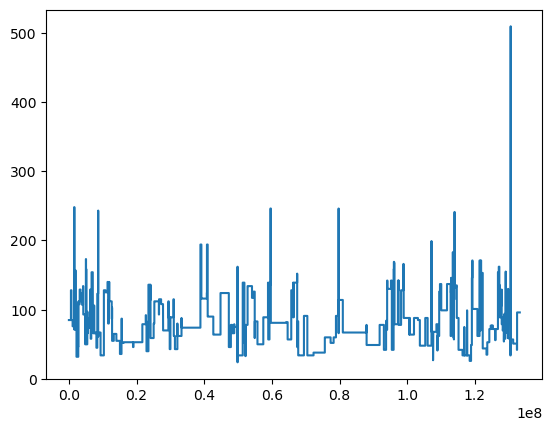

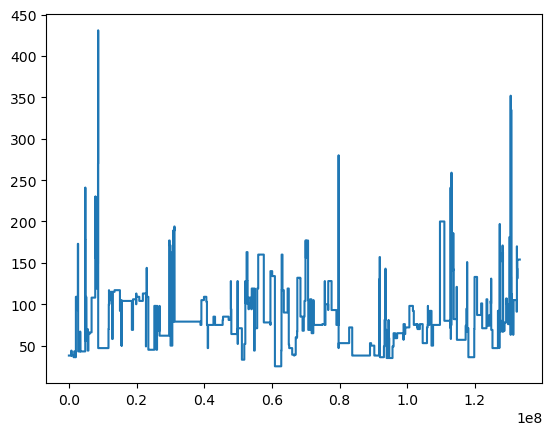

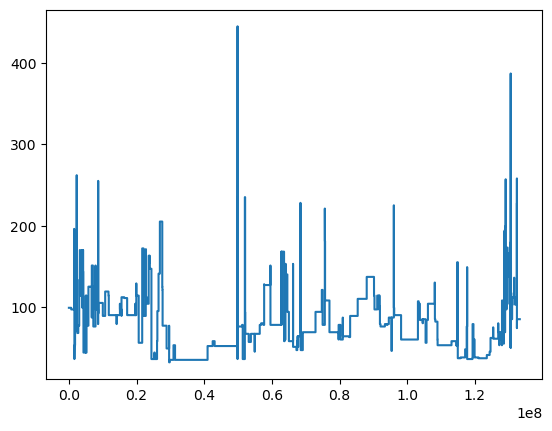

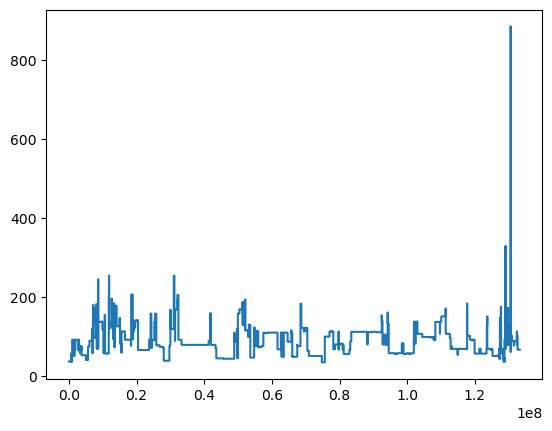

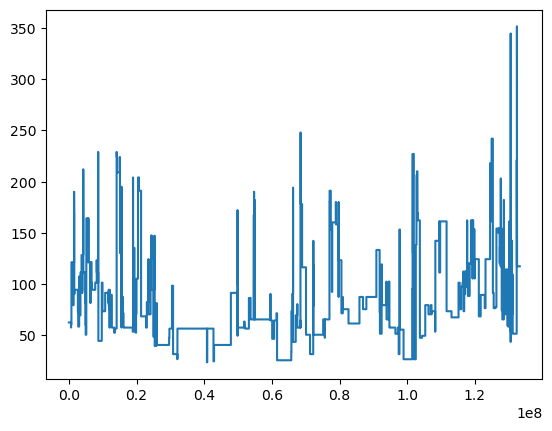

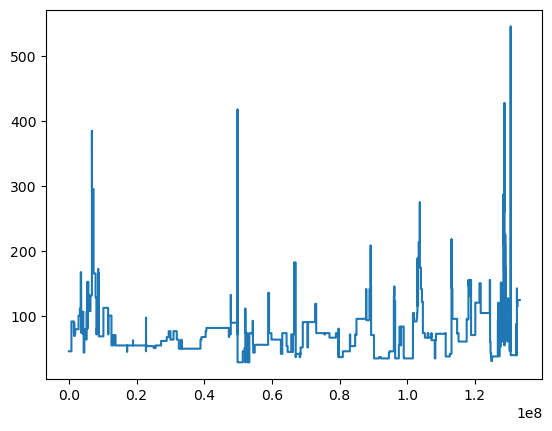

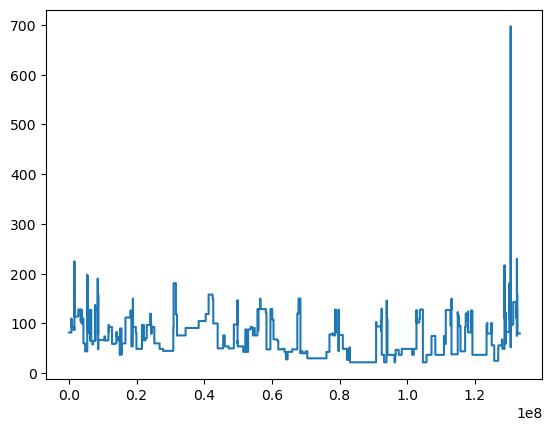

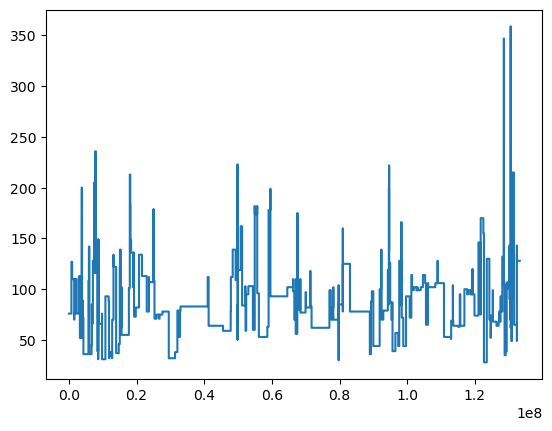

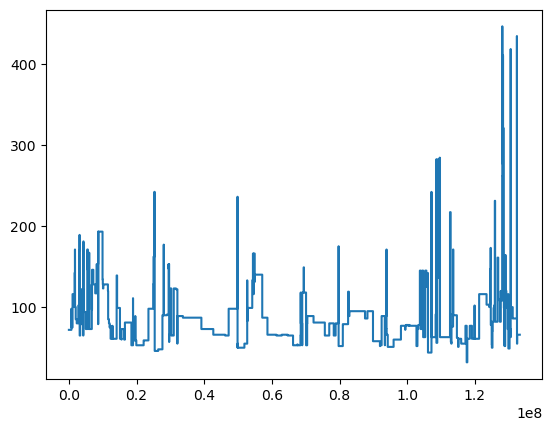

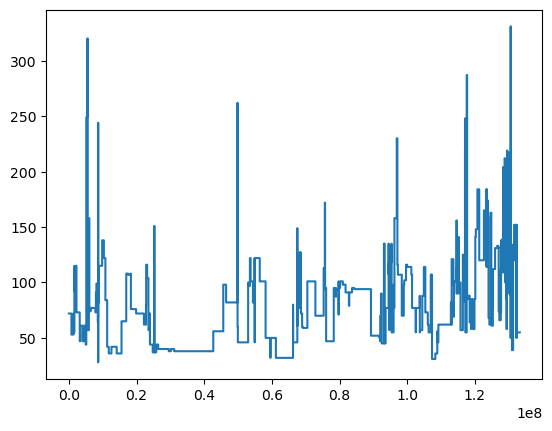

In [7]:
for recap in recap_list:
    breakpoints = list(recap.breakpoints())
    heights = tree_heights(recap)
    plt.step(breakpoints, heights, where='post')
    plt.show()

In [8]:
mts_list = []

for recap in recap_list:
    tree = recap.simplify()
    next_id = pyslim.next_slim_mutation_id(tree)
    mts = msprime.sim_mutations(
            tree,
            rate=1e-6,
            model=msprime.SLiMMutationModel(type=0, next_id=next_id),
            keep=True,
    )
    mts_list.append(mts)

In [9]:
# for mts in mts_list:
#     windows = np.linspace(0, mts.sequence_length, 1300)
#     pi = mts.diversity(mts.samples(), windows=windows)
#     taj_d = mts.Tajimas_D(mts.samples(), windows=windows)
#     plt.figure(figsize=(10, 6))
#     plt.scatter(windows[1:],pi)
#     plt.show() 

In [10]:
rates_df = pd.DataFrame({
        'left': recomb_map.position[:-1].astype(int),  
        'right': recomb_map.position[1:].astype(int),     
        'rate': recomb_map.rate             
    })
rates_df['mid'] = rates_df['left']+((rates_df['right']-rates_df['left']) // 2)
rates_df['span'] = rates_df['right']-rates_df['left']

In [11]:
df_list = []
for mts in mts_list:
    windows = np.linspace(0, mts.sequence_length, 1300)
    pi = mts.diversity(mts.samples(), windows=windows)
    taj_d = mts.Tajimas_D(mts.samples(), windows=windows)
    windows = windows.astype(int)
    df = pd.DataFrame({'left':(windows[:len(windows)-1]),'right':windows[1:],'pi':pi})
    df['mid'] = df['left']+((df['right']-df['left']) // 2)
    df['span'] = df['right']-df['left']
    ############
    rate_intervals = IntervalIndex.from_arrays(rates_df['left'], rates_df['right'], closed='both')
    result = df.copy()
    weighted_rates = []
    for idx, window in df.iterrows():
        window_left = window['left']
        window_right = window['right']
        # Find overlapping intervals
        overlap_mask = rate_intervals.overlaps(pd.Interval(window_left, window_right, closed='both'))
        overlapping_rates = rates_df[overlap_mask].copy()
        if len(overlapping_rates) == 0:
            weighted_rates.append(np.nan)
        else:
            # Calculate overlap lengths
            overlap_starts = np.maximum(overlapping_rates['left'].values, window_left)
            overlap_ends = np.minimum(overlapping_rates['right'].values, window_right)
            overlap_lengths = overlap_ends - overlap_starts
        # Calculate weighted mean
            weights = overlap_lengths / overlap_lengths.sum()
            weighted_rate = (overlapping_rates['rate'].values * weights).sum()
            weighted_rates.append(weighted_rate)

    result['rate'] = weighted_rates
    df_list.append(result)

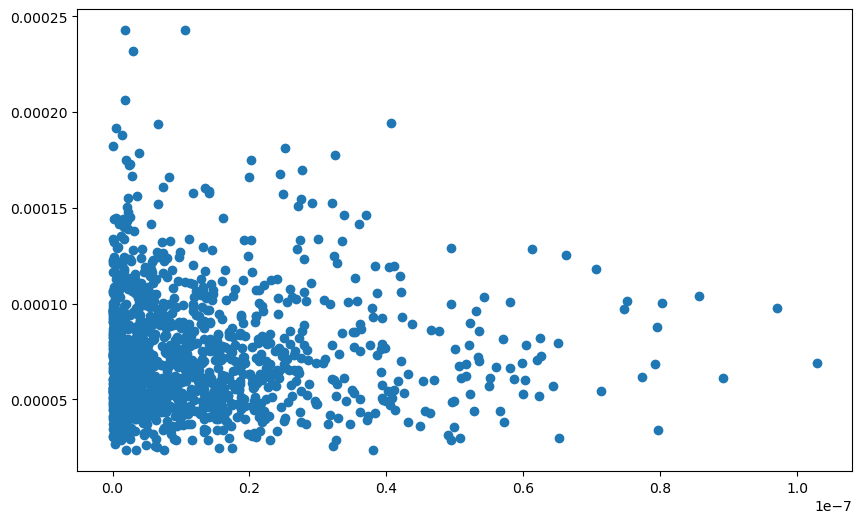

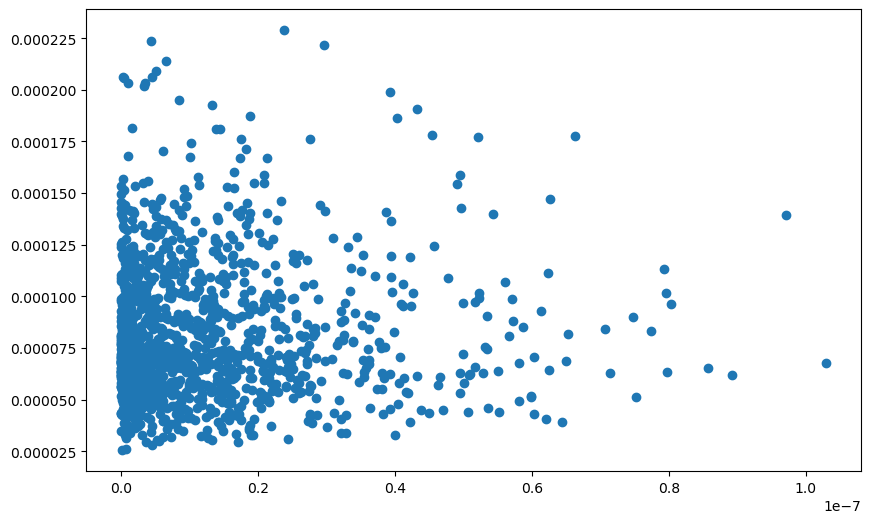

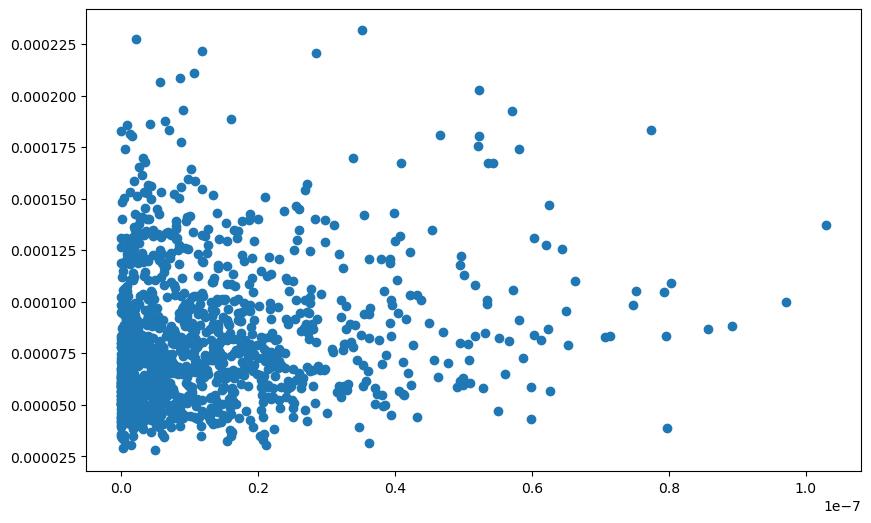

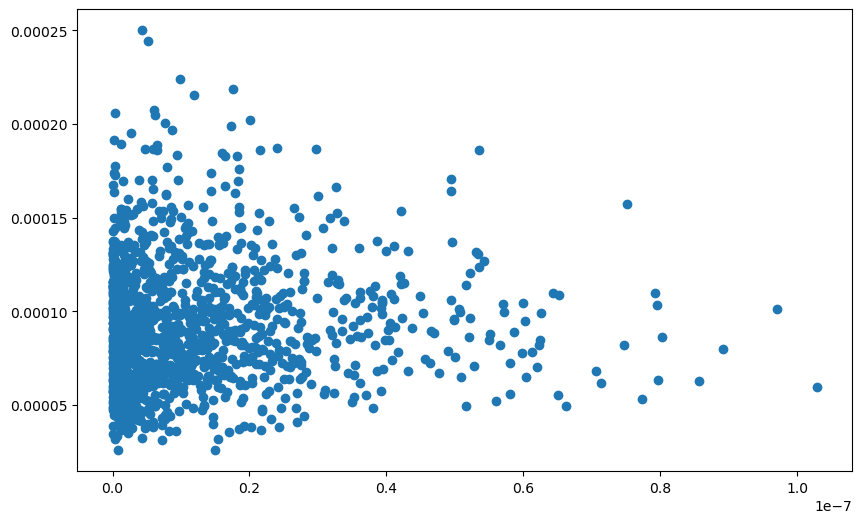

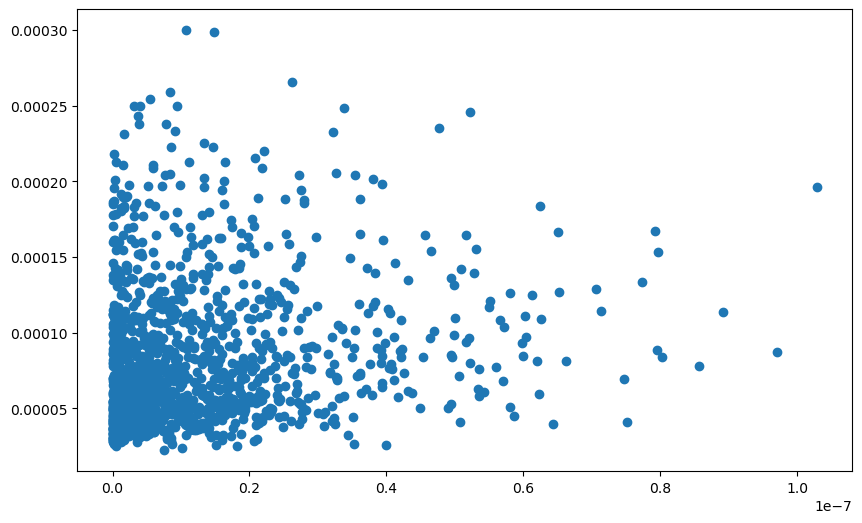

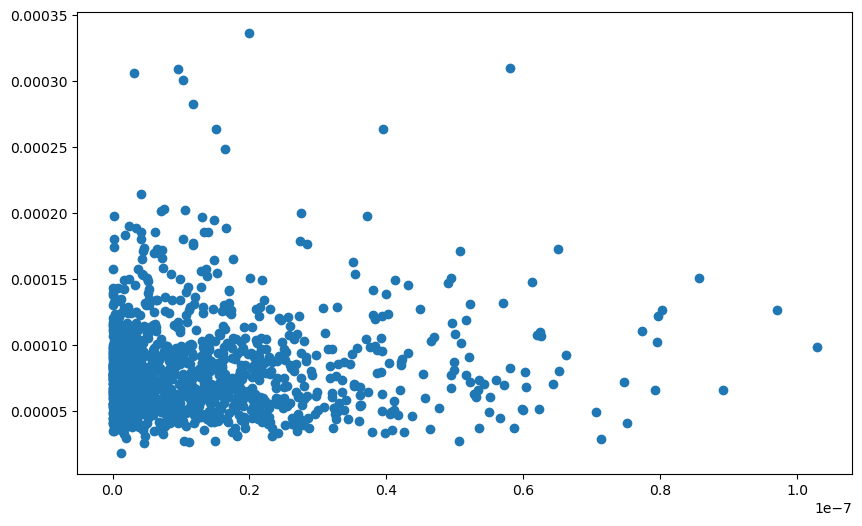

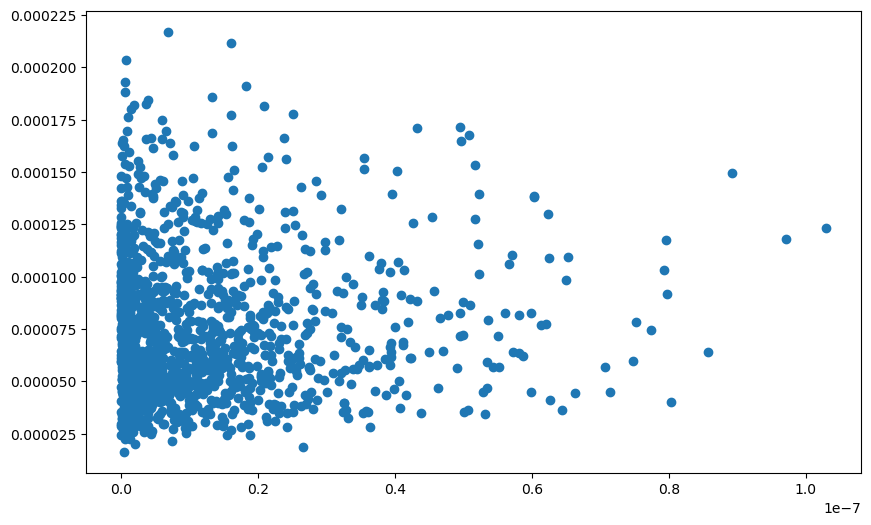

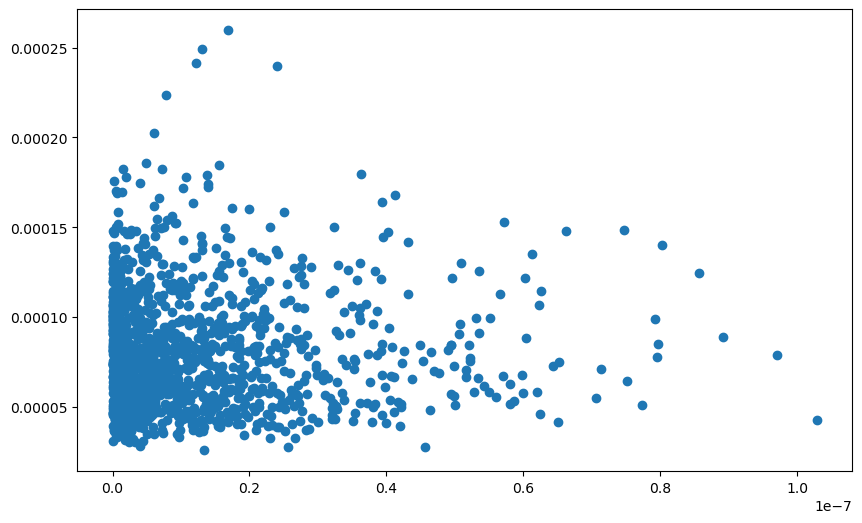

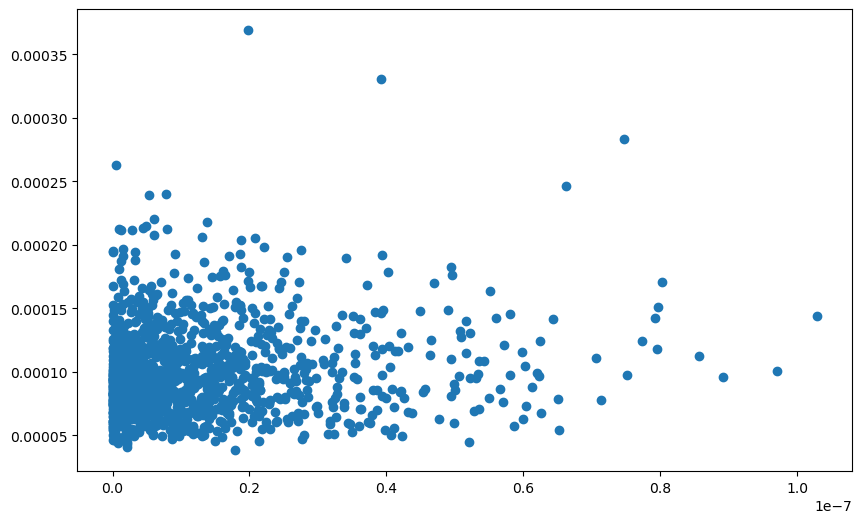

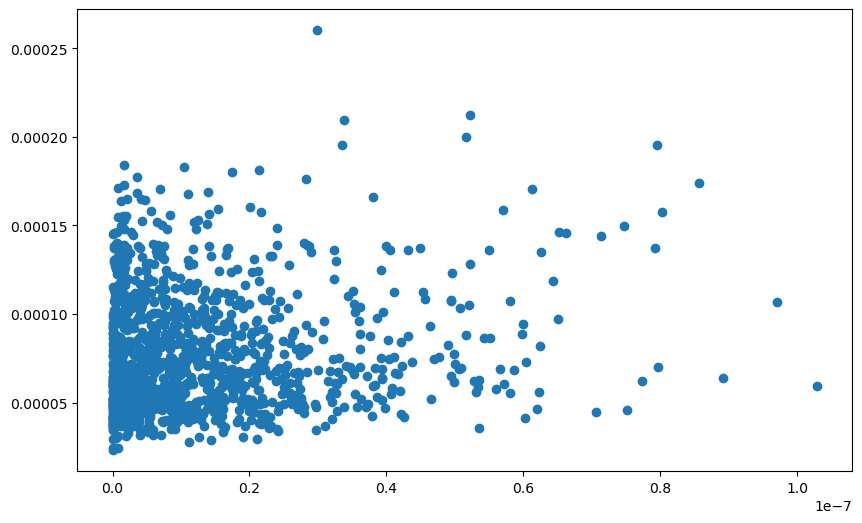

In [12]:
for result in df_list:
    plt.figure(figsize=(10, 6))
    plt.scatter(result['rate'],result['pi'])
    plt.show()

In [13]:
result_list = []
for result in df_list:
    result['bin'] = pd.cut(result['rate'], bins=20)
    result_list.append(result)

In [14]:
result_list

[           left      right        pi        mid    span  rate  \
 0             0     102598  0.000072      51299  102598   0.0   
 1        102598     205196  0.000054     153897  102598   0.0   
 2        205196     307795  0.000060     256495  102599   0.0   
 3        307795     410393  0.000067     359094  102598   0.0   
 4        410393     512991  0.000057     461692  102598   0.0   
 ...         ...        ...       ...        ...     ...   ...   
 1294  132762318  132864916  0.000056  132813617  102598   0.0   
 1295  132864916  132967514  0.000056  132916215  102598   0.0   
 1296  132967514  133070113  0.000069  133018813  102599   0.0   
 1297  133070113  133172711  0.000055  133121412  102598   0.0   
 1298  133172711  133275310  0.000078  133224010  102599   0.0   
 
                         bin  
 0     (-1.03e-10, 5.15e-09]  
 1     (-1.03e-10, 5.15e-09]  
 2     (-1.03e-10, 5.15e-09]  
 3     (-1.03e-10, 5.15e-09]  
 4     (-1.03e-10, 5.15e-09]  
 ...                

In [15]:
df_list_with_rep = []
for i, df in enumerate(df_list):
    df_copy = df.copy()
    df_copy['replicate'] = i  # or i+1 if you want 1-indexed
    df_list_with_rep.append(df_copy)

merged_df = pd.concat(df_list_with_rep, ignore_index=True)

In [16]:
merged_df

,left,right,pi,mid,span,rate,bin,replicate
0,0,102598,0.000072,51299,102598,0.0,"(-1.03e-10, 5.15e-09]",0
1,102598,205196,0.000054,153897,102598,0.0,"(-1.03e-10, 5.15e-09]",0
2,205196,307795,0.000060,256495,102599,0.0,"(-1.03e-10, 5.15e-09]",0
3,307795,410393,0.000067,359094,102598,0.0,"(-1.03e-10, 5.15e-09]",0
4,410393,512991,0.000057,461692,102598,0.0,"(-1.03e-10, 5.15e-09]",0
...,...,...,...,...,...,...,...,...
12985,132762318,132864916,0.000076,132813617,102598,0.0,"(-1.03e-10, 5.15e-09]",9
12986,132864916,132967514,0.000080,132916215,102598,0.0,"(-1.03e-10, 5.15e-09]",9
12987,132967514,133070113,0.000076,133018813,102599,0.0,"(-1.03e-10, 5.15e-09]",9
12988,133070113,133172711,0.000064,133121412,102598,0.0,"(-1.03e-10, 5.15e-09]",9


In [17]:
grouped_df = merged_df.groupby('bin').median()

/tmp/ipykernel_3363681/3024996743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = merged_df.groupby('bin').median()


In [18]:
grouped_df

,left,right,pi,mid,span,rate,replicate
bin,,,,,,,
"(-1.03e-10, 5.15e-09]",62072026.0,62174624.0,0.000073,62123325.0,102598.0,1.450913e-09,4.5
"(5.15e-09, 1.03e-08]",66945449.5,67048048.0,0.000074,66996748.5,102598.0,7.440334e-09,4.5
"(1.03e-08, 1.54e-08]",62790214.5,62892813.5,0.000077,62841513.5,102598.0,1.303748e-08,4.5
"(1.54e-08, 2.06e-08]",68381827.0,68484425.5,0.000076,68433126.0,102598.0,1.754882e-08,4.5
"(2.06e-08, 2.57e-08]",68946118.5,69048716.5,0.000077,68997417.5,102598.0,2.248511e-08,4.5
"(2.57e-08, 3.09e-08]",70690291.0,70792889.0,0.000079,70741590.0,102598.0,2.757676e-08,4.5
"(3.09e-08, 3.6e-08]",96237290.0,96339889.0,0.000076,96288589.0,102598.0,3.286544e-08,4.5
"(3.6e-08, 4.12e-08]",76128006.0,76230604.0,0.000082,76179305.0,102598.0,3.865419e-08,4.5
"(4.12e-08, 4.63e-08]",95826897.0,95929495.0,0.000084,95878196.0,102598.0,4.287633e-08,4.5


In [19]:
grouped_df['cm_mb']=grouped_df['rate']*1e8

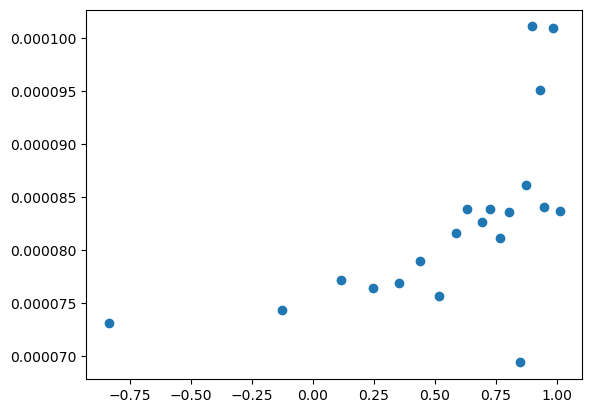

In [20]:
plt.scatter(np.log10(grouped_df['cm_mb']),grouped_df['pi'])

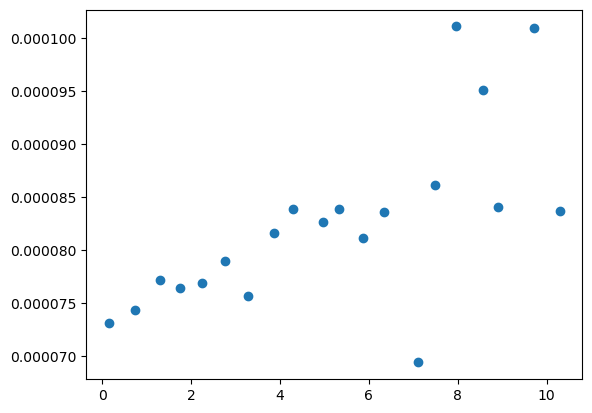

In [21]:
plt.scatter(grouped_df['cm_mb'],grouped_df['pi'])

In [22]:
grouped_df.to_csv('results/median_{ne}_s_{s}_df.csv'.format(ne=ne,s=s))